In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import os
os.chdir("/content")
print(os.getcwd())


/content


In [3]:
!rm -rf /content/Task-driven-low-light-enhancement
!git clone https://github.com/SarthakBaghel/Task-driven-low-light-enhancement.git /content/Task-driven-low-light-enhancement
%cd /content/Task-driven-low-light-enhancement
!pip install -r requirements.txt


Cloning into '/content/Task-driven-low-light-enhancement'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 68 (delta 12), reused 63 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 150.09 KiB | 1.85 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Task-driven-low-light-enhancement
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [4]:
from pathlib import Path
import shutil
import csv
import cv2
import numpy as np
from dataclasses import asdict

from low_light_simulator import LowLightConfig, read_image, degrade_image, VALID_IMAGE_EXTENSIONS

DRIVE_ROOT = Path("/content/drive/MyDrive")
PIPELINE_ROOT = DRIVE_ROOT / "task_driven_video_pipeline"
KAGGLE_V1_ROOT = PIPELINE_ROOT / "kaggle_v1"

RUN_TAG = "subject_class_balanced_20k"

TRAIN_CLEAN_ROOT = KAGGLE_V1_ROOT / f"train_clean_{RUN_TAG}"
VAL_CLEAN_ROOT = KAGGLE_V1_ROOT / f"val_clean_{RUN_TAG}"
TEST_CLEAN_ROOT = KAGGLE_V1_ROOT / f"test_clean_{RUN_TAG}"

TRAIN_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"train_lowlight_{RUN_TAG}_eye_mid"
VAL_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"val_lowlight_{RUN_TAG}_eye_mid"
TEST_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"test_lowlight_{RUN_TAG}_eye_mid"

assert TRAIN_CLEAN_ROOT.exists(), f"Missing: {TRAIN_CLEAN_ROOT}"
assert VAL_CLEAN_ROOT.exists(), f"Missing: {VAL_CLEAN_ROOT}"
assert TEST_CLEAN_ROOT.exists(), f"Missing: {TEST_CLEAN_ROOT}"

print("TRAIN_CLEAN_ROOT:", TRAIN_CLEAN_ROOT)
print("VAL_CLEAN_ROOT:", VAL_CLEAN_ROOT)
print("TEST_CLEAN_ROOT:", TEST_CLEAN_ROOT)
print("TRAIN_LOWLIGHT_ROOT:", TRAIN_LOWLIGHT_ROOT)
print("VAL_LOWLIGHT_ROOT:", VAL_LOWLIGHT_ROOT)
print("TEST_LOWLIGHT_ROOT:", TEST_LOWLIGHT_ROOT)


TRAIN_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k
VAL_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k
TEST_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_clean_subject_class_balanced_20k
TRAIN_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid
VAL_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid
TEST_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_lowlight_subject_class_balanced_20k_eye_mid


In [5]:
EYE_MID_CONFIG = LowLightConfig(
    gamma=1.75,
    brightness_factor=0.72,
    contrast_factor=0.84,
    black_level_shift=0.02,
    gaussian_sigma=1.5,
    poisson_strength=0.08,
    motion_blur_kernel=0,
    motion_blur_angle=0.0,
    desaturation_factor=0.00,
)

print(EYE_MID_CONFIG)


LowLightConfig(gamma=1.75, brightness_factor=0.72, contrast_factor=0.84, black_level_shift=0.02, gaussian_sigma=1.5, poisson_strength=0.08, motion_blur_kernel=0, motion_blur_angle=0.0, desaturation_factor=0.0)


In [6]:
def collect_class_images(root: Path):
    images_by_class = {}
    for class_name in ["open", "closed"]:
        class_dir = root / class_name
        assert class_dir.exists(), f"Missing class dir: {class_dir}"
        image_paths = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTENSIONS
        )
        images_by_class[class_name] = image_paths
    return images_by_class

for clean_root in [TRAIN_CLEAN_ROOT, VAL_CLEAN_ROOT, TEST_CLEAN_ROOT]:
    images_by_class = collect_class_images(clean_root)
    print(clean_root.name)
    for class_name, paths in images_by_class.items():
        print(" ", class_name, len(paths))


train_clean_subject_class_balanced_20k
  open 383
  closed 383
val_clean_subject_class_balanced_20k
  open 973
  closed 973
test_clean_subject_class_balanced_20k
  open 8644
  closed 8644


In [7]:
for root in [TRAIN_LOWLIGHT_ROOT, VAL_LOWLIGHT_ROOT, TEST_LOWLIGHT_ROOT]:
    if root.exists():
        shutil.rmtree(root)
        print("Deleted:", root)


In [8]:
LOG_FIELDNAMES = [
    "class_name",
    "original_file",
    "output_file",
    "profile",
    "effects_used",
    "gamma",
    "brightness_factor",
    "contrast_factor",
    "black_level_shift",
    "gaussian_sigma",
    "poisson_strength",
    "motion_blur_kernel",
    "motion_blur_angle",
    "desaturation_factor",
]

def generate_lowlight_copy(
    input_root: Path,
    output_root: Path,
    config: LowLightConfig,
    *,
    profile_name: str = "eye_mid",
    report_every: int = 1000,
):
    images_by_class = collect_class_images(input_root)

    if output_root.exists():
        shutil.rmtree(output_root)
    (output_root / "open").mkdir(parents=True, exist_ok=True)
    (output_root / "closed").mkdir(parents=True, exist_ok=True)

    all_items = []
    for class_name in ["open", "closed"]:
        for image_path in images_by_class[class_name]:
            all_items.append((class_name, image_path))

    log_rows = []
    total = len(all_items)

    for idx, (class_name, image_path) in enumerate(all_items, start=1):
        if idx == 1 or idx % report_every == 0:
            print(f"{output_root.name}: {idx}/{total}")

        relative_path = image_path.relative_to(input_root / class_name)
        dest_path = output_root / class_name / relative_path
        dest_path.parent.mkdir(parents=True, exist_ok=True)

        original_bgr = read_image(image_path)
        degraded_bgr = degrade_image(
            original_bgr,
            config,
            rng=np.random.default_rng(42 + idx),
        )

        ok = cv2.imwrite(str(dest_path), degraded_bgr)
        if not ok:
            raise RuntimeError(f"Failed to save image: {dest_path}")

        log_rows.append({
            "class_name": class_name,
            "original_file": str(Path(class_name) / relative_path),
            "output_file": str(Path(class_name) / relative_path),
            "profile": profile_name,
            "effects_used": "manual_config",
            **asdict(config),
        })

    log_path = output_root / "degradation_log.csv"
    with log_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=LOG_FIELDNAMES)
        writer.writeheader()
        writer.writerows(log_rows)

    print("Saved low-light root:", output_root)
    print("Saved log:", log_path)


In [10]:
generate_lowlight_copy(
    TRAIN_CLEAN_ROOT,
    TRAIN_LOWLIGHT_ROOT,
    EYE_MID_CONFIG,
    profile_name="eye_mid",
    report_every=1000,
)


train_lowlight_subject_class_balanced_20k_eye_mid: 1/766
Saved low-light root: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid
Saved log: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid/degradation_log.csv


In [11]:
generate_lowlight_copy(
    VAL_CLEAN_ROOT,
    VAL_LOWLIGHT_ROOT,
    EYE_MID_CONFIG,
    profile_name="eye_mid",
    report_every=500,
)


val_lowlight_subject_class_balanced_20k_eye_mid: 1/1946
val_lowlight_subject_class_balanced_20k_eye_mid: 500/1946
val_lowlight_subject_class_balanced_20k_eye_mid: 1000/1946
val_lowlight_subject_class_balanced_20k_eye_mid: 1500/1946
Saved low-light root: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid
Saved log: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid/degradation_log.csv


In [12]:
generate_lowlight_copy(
    TEST_CLEAN_ROOT,
    TEST_LOWLIGHT_ROOT,
    EYE_MID_CONFIG,
    profile_name="eye_mid",
    report_every=500,
)


test_lowlight_subject_class_balanced_20k_eye_mid: 1/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 1000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 1500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 2000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 2500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 3000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 3500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 4000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 4500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 5000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 5500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 6000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 6500/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 7000/17288
test_lowlight_subject_class_balanced_20k_eye_mid: 7500/17288
test_lowlight_subject_class_

In [13]:
!find "{TRAIN_LOWLIGHT_ROOT}/open" -type f | wc -l
!find "{TRAIN_LOWLIGHT_ROOT}/closed" -type f | wc -l

!find "{VAL_LOWLIGHT_ROOT}/open" -type f | wc -l
!find "{VAL_LOWLIGHT_ROOT}/closed" -type f | wc -l

!find "{TEST_LOWLIGHT_ROOT}/open" -type f | wc -l
!find "{TEST_LOWLIGHT_ROOT}/closed" -type f | wc -l


383
383
973
973
8644
8644


In [14]:
!ls "{TRAIN_LOWLIGHT_ROOT}/degradation_log.csv"
!ls "{VAL_LOWLIGHT_ROOT}/degradation_log.csv"
!ls "{TEST_LOWLIGHT_ROOT}/degradation_log.csv"

!sed -n '1,8p' "{TRAIN_LOWLIGHT_ROOT}/degradation_log.csv"


/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid/degradation_log.csv
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid/degradation_log.csv
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_lowlight_subject_class_balanced_20k_eye_mid/degradation_log.csv
class_name,original_file,output_file,profile,effects_used,gamma,brightness_factor,contrast_factor,black_level_shift,gaussian_sigma,poisson_strength,motion_blur_kernel,motion_blur_angle,desaturation_factor
open,open/s0002_01008_0_0_1_0_0_01.png,open/s0002_01008_0_0_1_0_0_01.png,eye_mid,manual_config,1.75,0.72,0.84,0.02,1.5,0.08,0,0.0,0.0
open,open/s0002_01009_0_0_1_0_0_01.png,open/s0002_01009_0_0_1_0_0_01.png,eye_mid,manual_config,1.75,0.72,0.84,0.02,1.5,0.08,0,0.0,0.0
open,open/s0002_01010_0_0_1_0_0_01.png,open/s0002_01010_0_0_1_0_0_01.png,eye_mid,manual_config,1.75,0.72,0.84,0.02,1.5,0.08,0,0.0,0.0
open,o

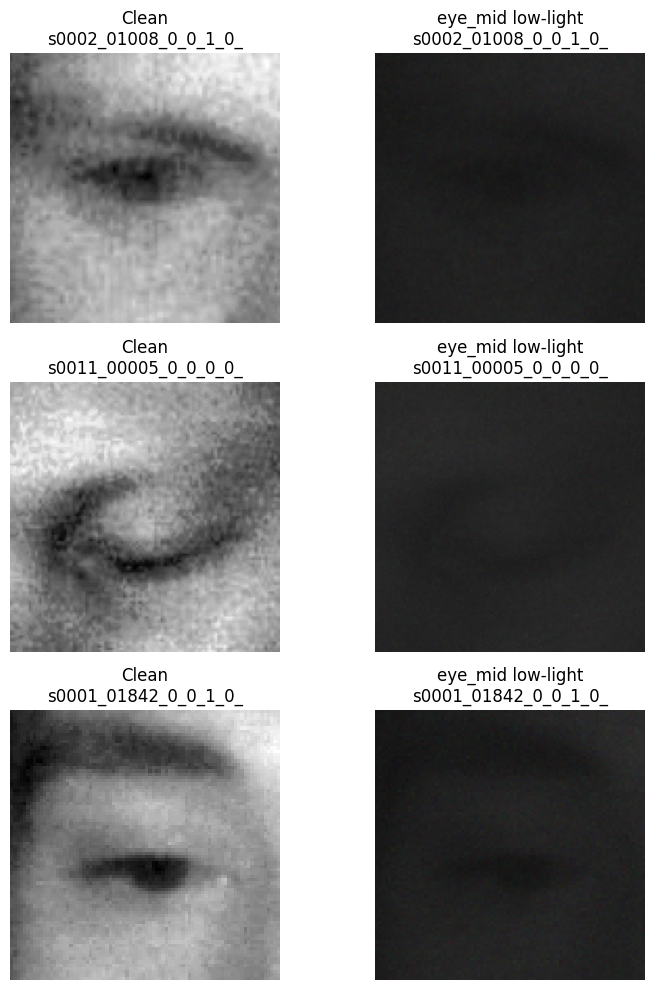

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

def first_image(root: Path, class_name: str):
    return sorted((root / class_name).rglob("*"))[0]

pairs = [
    (first_image(TRAIN_CLEAN_ROOT, "open"), first_image(TRAIN_LOWLIGHT_ROOT, "open")),
    (first_image(VAL_CLEAN_ROOT, "closed"), first_image(VAL_LOWLIGHT_ROOT, "closed")),
    (first_image(TEST_CLEAN_ROOT, "open"), first_image(TEST_LOWLIGHT_ROOT, "open")),
]

fig, axes = plt.subplots(len(pairs), 2, figsize=(8, 10))

for row_idx, (clean_path, lowlight_path) in enumerate(pairs):
    clean_img = Image.open(clean_path)
    lowlight_img = Image.open(lowlight_path)

    axes[row_idx, 0].imshow(clean_img, cmap="gray")
    axes[row_idx, 0].set_title(f"Clean\n{clean_path.name[:20]}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(lowlight_img, cmap="gray")
    axes[row_idx, 1].set_title(f"eye_mid low-light\n{lowlight_path.name[:20]}")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()


In [16]:
print("Phase 5 complete.")
print("TRAIN_LOWLIGHT_ROOT:", TRAIN_LOWLIGHT_ROOT)
print("VAL_LOWLIGHT_ROOT:", VAL_LOWLIGHT_ROOT)
print("TEST_LOWLIGHT_ROOT:", TEST_LOWLIGHT_ROOT)


Phase 5 complete.
TRAIN_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid
VAL_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid
TEST_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_lowlight_subject_class_balanced_20k_eye_mid
